In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#basic libraries import
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import re

In [4]:
%matplotlib inline
import plotly.express as px

In [5]:
ccdf = pd.read_csv("/content/drive/My Drive/Colabnotebooks/CustomerChurnData.csv")

In [6]:
ccdf.head()

,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,20000,1,4,3.0,6.0,Debit Card,Female,3.0,3,Super,2.0,Single,9,1.0,11,1,5,160,Mobile
1,20001,1,0,1.0,8.0,UPI,Male,3.0,4,Regular Plus,3.0,Single,7,1.0,15,0,0,121,Mobile
2,20002,1,0,1.0,30.0,Debit Card,Male,2.0,4,Regular Plus,3.0,Single,6,1.0,14,0,3,NaN,Mobile
3,20003,1,0,3.0,15.0,Debit Card,Male,2.0,4,Super,5.0,Single,8,0.0,23,0,3,134,Mobile
4,20004,1,0,1.0,12.0,Credit Card,Male,2.0,3,Regular Plus,5.0,Single,3,0.0,11,1,3,130,Mobile


In [7]:
ccdf.tail()

,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
11255,31255,0,10,1.0,34.0,Credit Card,Male,3.0,2,Super,1.0,Married,9,0.0,19,1,4,154,Computer
11256,31256,0,13,1.0,19.0,Credit Card,Male,3.0,5,HNI,5.0,Married,7,0.0,16,1,8,227,Mobile
11257,31257,0,1,1.0,14.0,Debit Card,Male,3.0,2,Super,4.0,Married,7,1.0,22,1,4,191,Mobile
11258,31258,0,23,3.0,11.0,Credit Card,Male,4.0,5,Super,4.0,Married,7,0.0,16,2,9,180,Computer
11259,31259,0,8,1.0,22.0,Credit Card,Male,3.0,2,Super,3.0,Married,5,0.0,13,2,3,175,Mobile


ccdf = ccdf.drop("AccountID",axis=1)

In [9]:
ccdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AccountID                11260 non-null  int64  
 1   Churn                    11260 non-null  int64  
 2   Tenure                   11158 non-null  object 
 3   City_Tier                11148 non-null  float64
 4   CC_Contacted_LY          11158 non-null  float64
 5   Payment                  11151 non-null  object 
 6   Gender                   11152 non-null  object 
 7   Service_Score            11162 non-null  float64
 8   Account_user_count       11148 non-null  object 
 9   account_segment          11163 non-null  object 
 10  CC_Agent_Score           11144 non-null  float64
 11  Marital_Status           11048 non-null  object 
 12  rev_per_month            11158 non-null  object 
 13  Complain_ly              10903 non-null  float64
 14  rev_growth_yoy        

In [10]:
ccdf.describe(include="all")

,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
count,11260.00000,11260.000000,11158,11148.000000,11158.000000,11151,11152,11162.000000,11148,11163,11144.000000,11048,11158,10903.000000,11260,11260,10903,10789,11039
unique,NaN,NaN,38,NaN,NaN,5,4,NaN,7,7,NaN,3,59,NaN,20,20,24,321,3
top,NaN,NaN,1,NaN,NaN,Debit Card,Male,NaN,4,Super,NaN,Married,3,NaN,14,1,3,152,Mobile
freq,NaN,NaN,1351,NaN,NaN,4587,6328,NaN,4569,4062,NaN,5860,1746,NaN,1524,4373,1816,208,7482
mean,25629.50000,0.168384,NaN,1.653929,17.867091,NaN,NaN,2.902526,NaN,NaN,3.066493,NaN,NaN,0.285334,NaN,NaN,NaN,NaN,NaN
std,3250.62635,0.374223,NaN,0.915015,8.853269,NaN,NaN,0.725584,NaN,NaN,1.379772,NaN,NaN,0.451594,NaN,NaN,NaN,NaN,NaN
min,20000.00000,0.000000,NaN,1.000000,4.000000,NaN,NaN,0.000000,NaN,NaN,1.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,22814.75000,0.000000,NaN,1.000000,11.000000,NaN,NaN,2.000000,NaN,NaN,2.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
50%,25629.50000,0.000000,NaN,1.000000,16.000000,NaN,NaN,3.000000,NaN,NaN,3.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
75%,28444.25000,0.000000,NaN,3.000000,23.000000,NaN,NaN,3.000000,NaN,NaN,4.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN


In [11]:
ccdf = ccdf.drop("AccountID", axis=1)
#dropping accountid notusable for prediction

In [15]:
ccdf["Tenure"][ccdf["Tenure"].apply(lambda x: bool(re.match(r'\D',str(x))))].value_counts()

,count
Tenure,
#,116


In [16]:
# filling null and illegal values with 0 missing value means no tenure recorded
ccdf["Tenure"]=ccdf["Tenure"].replace("#",0)
ccdf["Tenure"]=ccdf["Tenure"].fillna(0)
ccdf["Tenure"]=ccdf["Tenure"].astype(int)

In [17]:
# Filling null value 0 as abasence of value indicate no customer connect since last year so 0
ccdf["CC_Contacted_LY"]=ccdf["CC_Contacted_LY"].fillna(0)

In [18]:
ccdf["Payment"]=ccdf["Payment"].fillna("Cash on Delivery")
# Filling null values with Cash on delivery because rest mode of payments can be recorded by the system as they are electronic systems

In [19]:
ccdf["Payment"].value_counts()

,count
Payment,
Debit Card,4587
Credit Card,3511
E wallet,1217
Cash on Delivery,1123
UPI,822


In [20]:
ccdf['Service_Score']= ccdf['Service_Score'].fillna(3.0)
#filling null values with median

In [22]:
ccdf["rev_per_month"][ccdf["rev_per_month"].apply(lambda x: bool(re.match(r'\D',str(x))))].value_counts()

,count
rev_per_month,
+,689


In [23]:
ccdf['rev_per_month']=ccdf['rev_per_month'].replace("+",0)
ccdf['rev_per_month']=ccdf['rev_per_month'].fillna(0)
ccdf['rev_per_month']=ccdf['rev_per_month'].astype(float)
#fillin null values and replacing illegal values with 0 absense in revenue means 0

In [24]:
ccdf['Complain_ly']=ccdf['Complain_ly'].fillna(0)
#missing values in column indicates no complaint last year raised by customer

In [25]:
ccdf["rev_growth_yoy"][ccdf["rev_growth_yoy"].apply(lambda x: bool(re.match(r'\D',str(x))))].value_counts()

,count
rev_growth_yoy,
$,3


In [26]:
ccdf["rev_growth_yoy"] = ccdf["rev_growth_yoy"].replace("$",0)

In [27]:
ccdf["rev_growth_yoy"] = ccdf["rev_growth_yoy"].astype(float)

In [30]:
ccdf['coupon_used_for_payment'][ccdf['coupon_used_for_payment'].apply(lambda x: bool(re.match(r'\D',str(x))))].value_counts()

,count
coupon_used_for_payment,
#,1
$,1
*,1


In [31]:
ccdf['coupon_used_for_payment']=ccdf['coupon_used_for_payment'].replace({"#":0,"$":0,"*":0})
ccdf['coupon_used_for_payment']=ccdf['coupon_used_for_payment'].astype(int)

In [33]:
ccdf['Day_Since_CC_connect'][ccdf['Day_Since_CC_connect'].apply(lambda x: bool(re.match(r'\D',str(x))))].value_counts()

,count
Day_Since_CC_connect,
$,1


In [34]:
ccdf['Day_Since_CC_connect']=ccdf['Day_Since_CC_connect'].replace("$",0)
ccdf['Day_Since_CC_connect']=ccdf['Day_Since_CC_connect'].astype(float)
ccdf['Day_Since_CC_connect']=ccdf['Day_Since_CC_connect'].fillna(0)

In [36]:
ccdf['cashback'][ccdf['cashback'].apply(lambda x: bool(re.match(r'\D',str(x))))].value_counts()

,count
cashback,
$,2


In [37]:
ccdf['cashback']=ccdf['cashback'].replace("$",0)
ccdf['cashback']=ccdf['cashback'].astype(float)
ccdf['cashback']=ccdf['cashback'].fillna(0)

In [38]:
ccdf['Login_device'].value_counts()

,count
Login_device,
Mobile,7482
Computer,3018
&&&&,539


In [39]:
ccdf['Login_device']=ccdf['Login_device'].fillna("Other Device")
ccdf['Login_device'] = ccdf['Login_device'].replace("&&&&","Other Device")

In [41]:
ccdf['Account_user_count'][ccdf['Account_user_count'].apply(lambda x: bool(re.match(r'\D',str(x))))].value_counts()

,count
Account_user_count,
@,332


In [42]:
ccdf['Account_user_count'] = ccdf['Account_user_count'].replace("@",1)
ccdf['Account_user_count'] = ccdf['Account_user_count'].fillna(1)
ccdf['Account_user_count'] = ccdf['Account_user_count'].astype(int)

In [43]:
ccdf["City_Tier"] = ccdf["City_Tier"].fillna(3.0)

In [44]:
ccdf["Gender"].value_counts()

,count
Gender,
Male,6328
Female,4178
M,376
F,270


In [45]:
ccdf["Gender"]= ccdf['Gender'].replace("M","Male")
ccdf["Gender"]= ccdf['Gender'].replace("F","Female")
ccdf['Gender'].value_counts()

,count
Gender,
Male,6704
Female,4448


In [46]:
ccdf["Gender"]=ccdf['Gender'].fillna("Male")

In [47]:
ccdf['account_segment'].value_counts()

,count
account_segment,
Super,4062
Regular Plus,3862
HNI,1639
Super Plus,771
Regular,520
Regular +,262
Super +,47


In [48]:
ccdf['account_segment']=ccdf['account_segment'].replace("Regular +","Regular Plus")
ccdf['account_segment']=ccdf['account_segment'].replace("Super +","Regular Plus")
ccdf['account_segment']=ccdf['account_segment'].fillna("Regular")
ccdf['account_segment'].value_counts()

,count
account_segment,
Regular Plus,4171
Super,4062
HNI,1639
Super Plus,771
Regular,617


In [49]:
ccdf['Marital_Status'].fillna("Single",inplace=True)

/tmp/ipython-input-4224752393.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ccdf['Marital_Status'].fillna("Single",inplace=True)


In [50]:
ccdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Churn                    11260 non-null  int64  
 1   Tenure                   11260 non-null  int64  
 2   City_Tier                11260 non-null  float64
 3   CC_Contacted_LY          11260 non-null  float64
 4   Payment                  11260 non-null  object 
 5   Gender                   11260 non-null  object 
 6   Service_Score            11260 non-null  float64
 7   Account_user_count       11260 non-null  int64  
 8   account_segment          11260 non-null  object 
 9   CC_Agent_Score           11144 non-null  float64
 10  Marital_Status           11260 non-null  object 
 11  rev_per_month            11260 non-null  float64
 12  Complain_ly              11260 non-null  float64
 13  rev_growth_yoy           11260 non-null  float64
 14  coupon_used_for_paymen

In [51]:
ccdf["CC_Agent_Score"] = ccdf["CC_Agent_Score"].fillna(3.0)

In [52]:
ccdf.describe(include="all")

,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
count,11260.000000,11260.000000,11260.000000,11260.000000,11260,11260,11260.000000,11260.000000,11260,11260.000000,11260,11260.000000,11260.000000,11260.000000,11260.000000,11260.000000,11260.000000,11260
unique,NaN,NaN,NaN,NaN,5,2,NaN,NaN,5,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Debit Card,Male,NaN,NaN,Regular Plus,NaN,Married,NaN,NaN,NaN,NaN,NaN,NaN,Mobile
freq,NaN,NaN,NaN,NaN,4587,6812,NaN,NaN,4171,NaN,5860,NaN,NaN,NaN,NaN,NaN,NaN,7482
mean,0.168384,10.811634,1.667318,17.705240,NaN,NaN,2.903375,3.586679,NaN,3.065808,NaN,5.915631,0.276288,16.189076,1.790142,4.485879,187.992096,NaN
std,0.374223,12.844640,0.920201,8.974194,NaN,NaN,0.722476,1.131327,NaN,1.372663,NaN,11.598273,0.447181,3.766505,1.969505,3.728088,179.240555,NaN
min,0.000000,0.000000,1.000000,0.000000,NaN,NaN,0.000000,1.000000,NaN,1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,0.000000,2.000000,1.000000,11.000000,NaN,NaN,2.000000,3.000000,NaN,2.000000,NaN,3.000000,0.000000,13.000000,1.000000,2.000000,145.000000,NaN
50%,0.000000,8.000000,1.000000,16.000000,NaN,NaN,3.000000,4.000000,NaN,3.000000,NaN,4.000000,0.000000,15.000000,1.000000,3.000000,163.000000,NaN
75%,0.000000,16.000000,3.000000,23.000000,NaN,NaN,3.000000,4.000000,NaN,4.000000,NaN,7.000000,1.000000,19.000000,2.000000,7.000000,197.000000,NaN


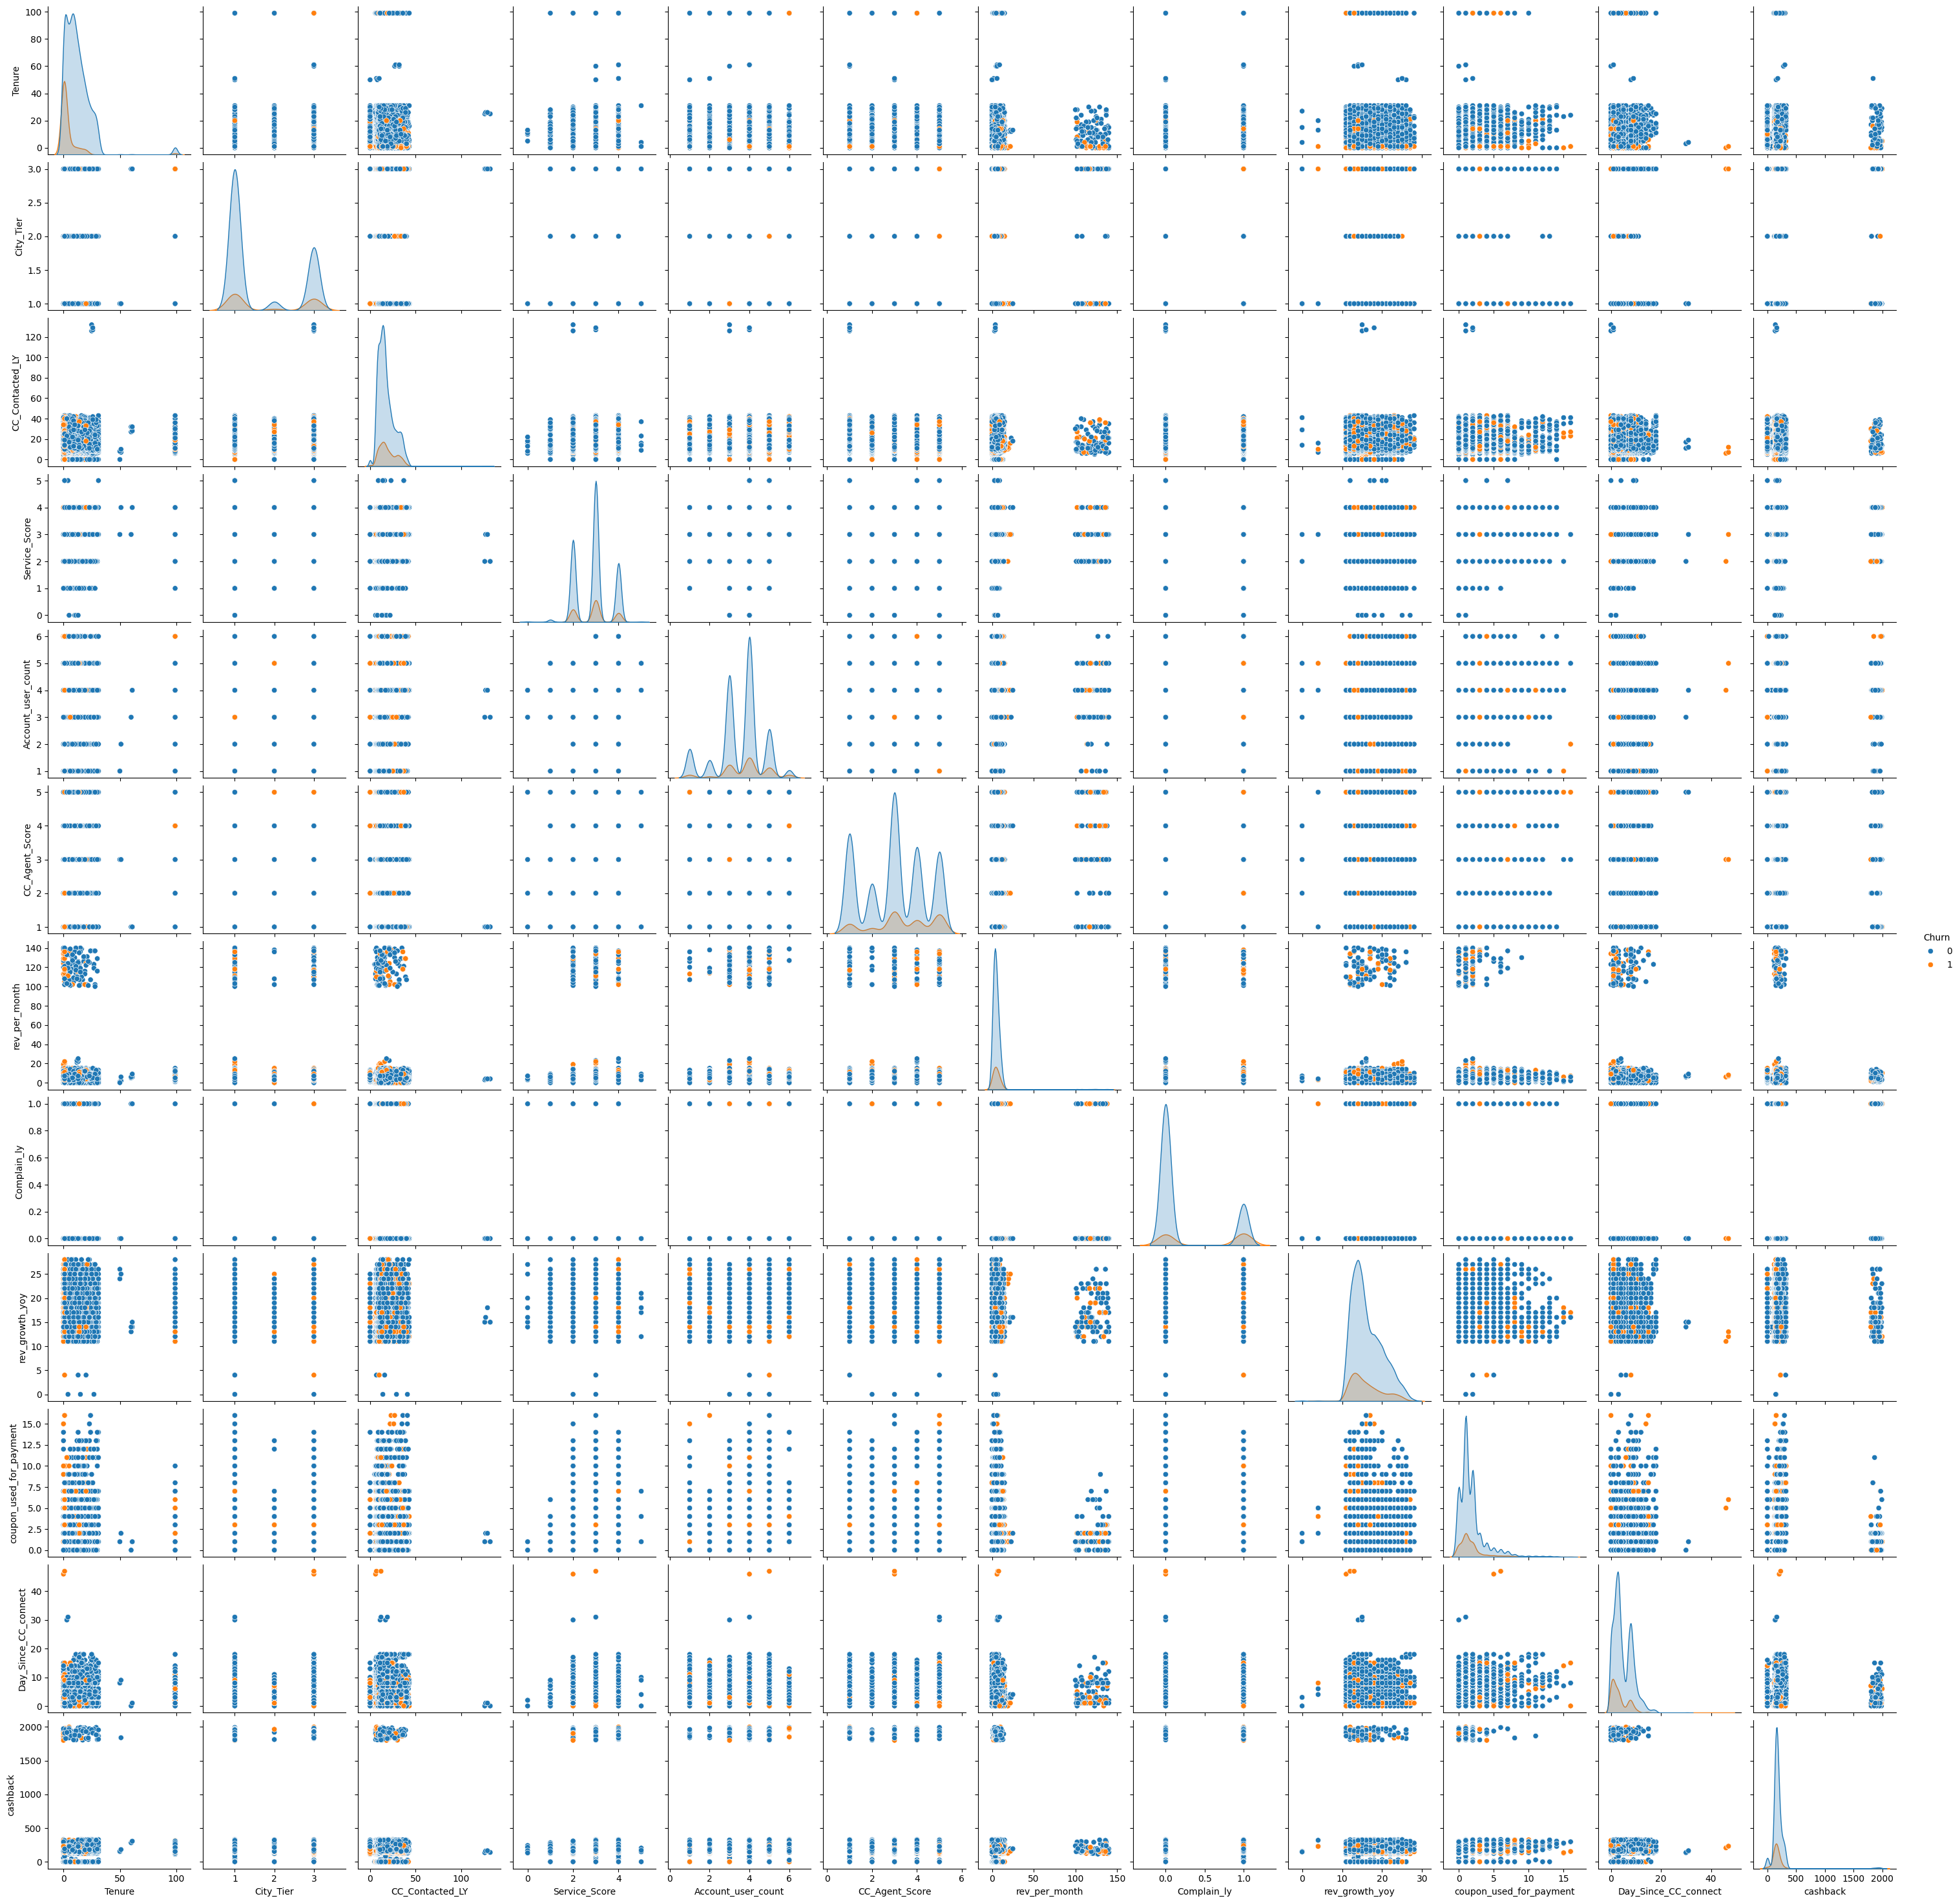

In [53]:
sns.pairplot(ccdf,hue="Churn",diag_kind="kde")

<Axes: xlabel='Churn', ylabel='count'>

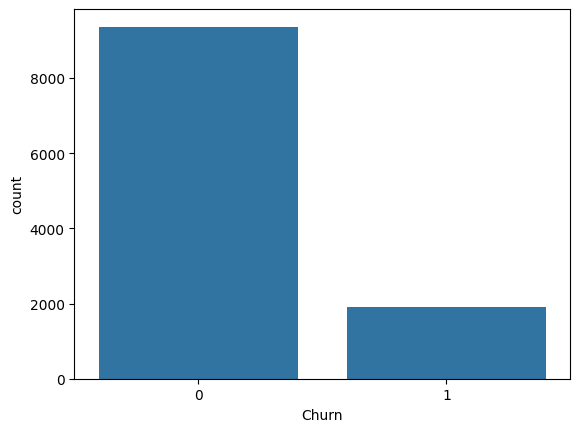

In [54]:
sns.countplot(data=ccdf,x='Churn')

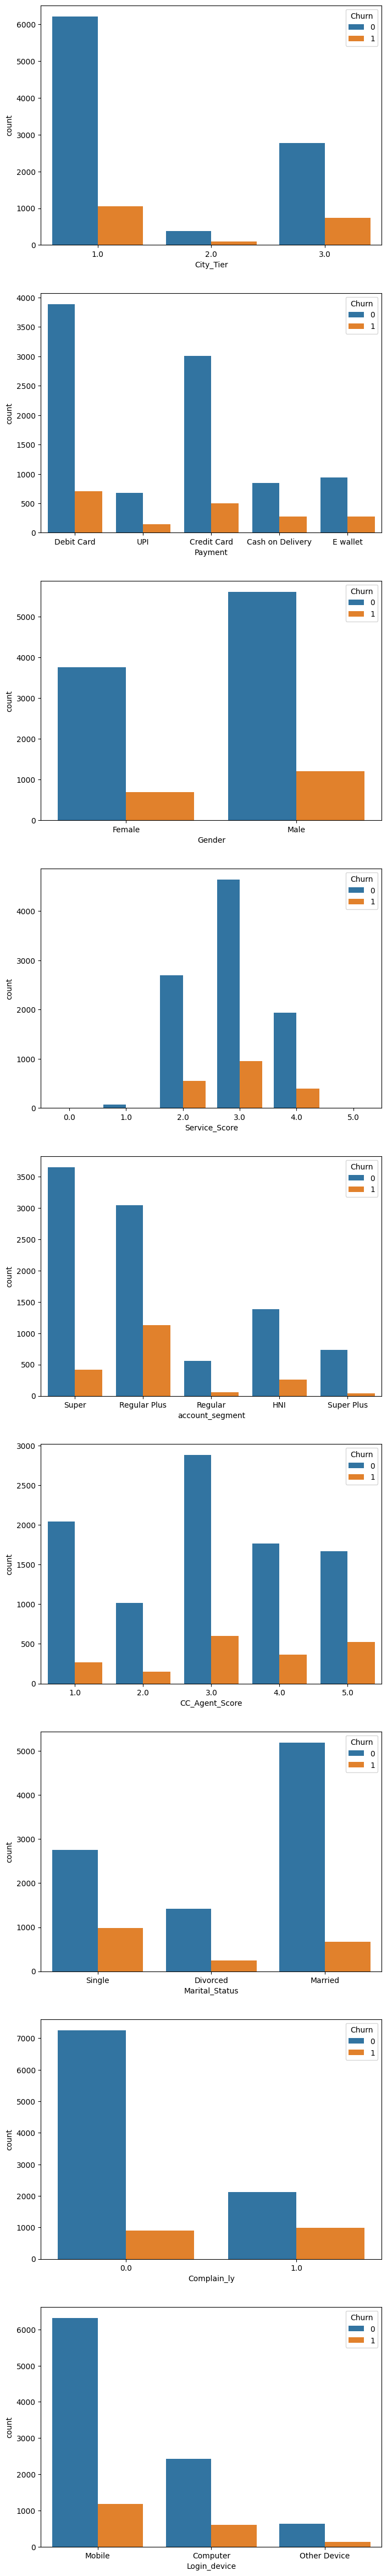

In [ ]:
mylist = ['City_Tier', 'Payment', 'Gender',
       'Service_Score', 'account_segment',
       'CC_Agent_Score', 'Marital_Status', 'Complain_ly', 'Login_device']
plt.figure(figsize=(8,60))
for i in range(9):
    plt.subplot(9,1,i+1)
    sns.countplot(data=ccdf,x=mylist[i],hue='Churn')


<Axes: xlabel='Account_user_count', ylabel='count'>

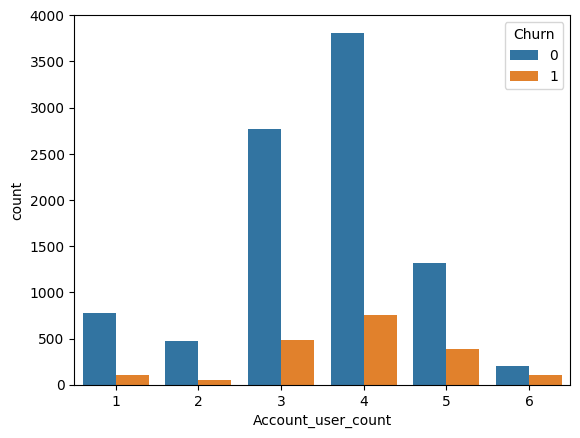

In [55]:
sns.countplot(data=ccdf,x='Account_user_count',hue='Churn')

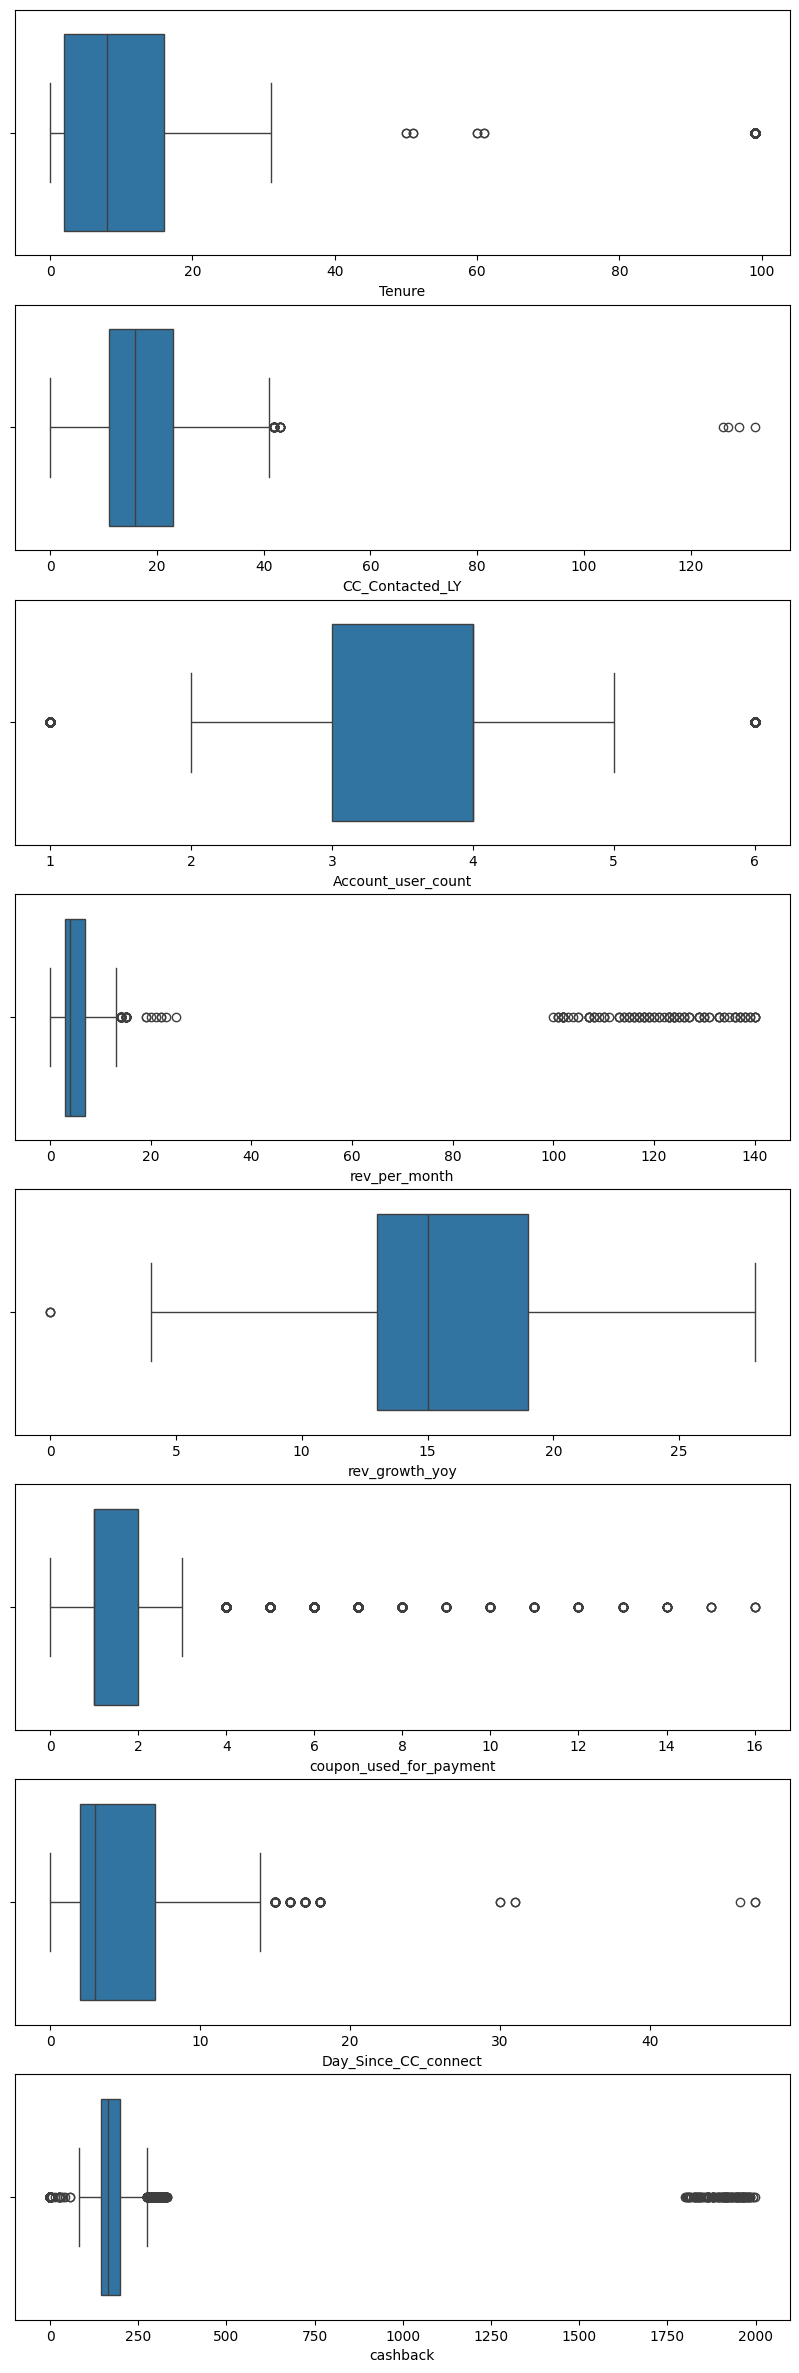

In [ ]:
mylist=['Tenure', 'CC_Contacted_LY', 'Account_user_count', 'rev_per_month',
       'rev_growth_yoy', 'coupon_used_for_payment', 'Day_Since_CC_connect',
       'cashback']
plt.figure(figsize=(10,30))
for i in range(8):
    plt.subplot(8,1,i+1)
    sns.boxplot(data=ccdf,x=mylist[i])

In [56]:
#handling  outliers
q3=16
q1=8
iqr=q3-q1
upperlimit=q3+1.5*iqr
lowerlimit=q1-1.5*iqr
ccdf['Tenure']=ccdf['Tenure'].apply(lambda x:upperlimit if x>upperlimit else (lowerlimit if x< lowerlimit else x))
q3=7
q1=2
iqr=q3-q1
upperlimit=q3+1.5*iqr
lowerlimit=q1-1.5*iqr
ccdf['Day_Since_CC_connect']=ccdf['Day_Since_CC_connect'].apply(lambda x:upperlimit if x>upperlimit else (lowerlimit if x< lowerlimit else x))
ccdf['Day_Since_CC_connect'].fillna(ccdf["Day_Since_CC_connect"].median(),inplace=True)
q3=23
q1=11
iqr=q3-q1
upperlimit=q3+1.5*iqr
lowerlimit=q1-1.5*iqr
ccdf['CC_Contacted_LY']=ccdf['CC_Contacted_LY'].apply(lambda x:upperlimit if x>upperlimit else (lowerlimit if x< lowerlimit else x))

/tmp/ipython-input-2581231662.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ccdf['Day_Since_CC_connect'].fillna(ccdf["Day_Since_CC_connect"].median(),inplace=True)


<Axes: xlabel='Tenure'>

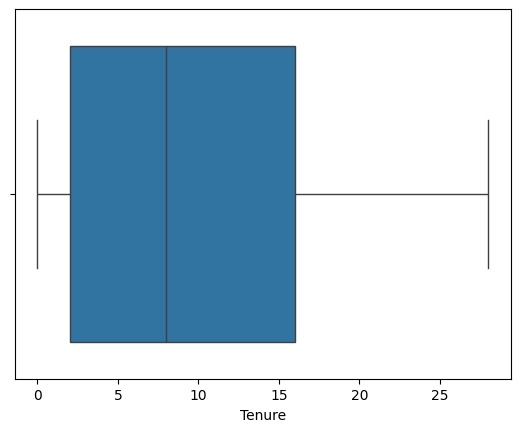

In [57]:
sns.boxplot(data=ccdf, x='Tenure')

In [58]:
tdf = ccdf[ccdf['Marital_Status'] == "Single"][['Churn','Marital_Status']].groupby("Churn").size()
val = (tdf[0],tdf[1])
labels = ["Not Churned",'Churned']
px.pie(values=val, names=labels)

In [59]:

def make_pie(x, col, width=500, height=500):

    tdf = ccdf[ccdf[x] == col][['Churn', x]].groupby("Churn").size()


    val = (tdf.get(0, 0), tdf.get(1, 0))


    labels = ["Not Churned", "Churned"]


    fig = px.pie(values=val, names=labels, title=f'Churn Rate for {x} : {col} Customers',
                 color_discrete_sequence=['skyblue', 'salmon'])


    fig.update_layout(
        width=width,
        height=height,
        title={'x': 0.5, 'xanchor': 'center'}
    )

    fig.show()



In [60]:
make_pie("Marital_Status", "Married")
make_pie("Marital_Status", "Single")
make_pie("Marital_Status", "Divorced")


In [61]:
make_pie('account_segment','Super Plus')
make_pie('account_segment','Regular Plus')
make_pie('account_segment','Regular')

In [62]:
make_pie('City_Tier',2)
make_pie('City_Tier',3)

In [63]:
from scipy.stats import f_oneway
def anova_feature_selection(df, continuous_features, target_variable, alpha=0.05):

    results = []

    for feature in continuous_features:

        churn_groups = [df[df[target_variable] == 0][feature], df[df[target_variable] == 1][feature]]


        f_stat, p_value = f_oneway(*churn_groups)


        decision = 'Keep' if p_value < alpha else 'Drop'


        results.append({'Feature': feature, 'p-value': p_value, 'Decision': decision})


    results_df = pd.DataFrame(results)

    return results_df


In [64]:
features = ['rev_per_month','rev_growth_yoy','coupon_used_for_payment','cashback']


In [65]:
anova_feature_selection(ccdf,features,'Churn')

,Feature,p-value,Decision
0,rev_per_month,0.013970,Keep
1,rev_growth_yoy,0.157353,Drop
2,coupon_used_for_payment,0.118436,Drop
3,cashback,0.000615,Keep


In [66]:
ccdf = ccdf.drop(['rev_growth_yoy','coupon_used_for_payment'],axis=1)

In [67]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder

In [68]:
ord_enc = OrdinalEncoder()
le = LabelEncoder()

In [70]:
ccdf['Gender']=le.fit_transform(ccdf['Gender'])
ccdf['Marital_Status']=le.fit_transform(ccdf['Marital_Status'])
ccdf['Payment']=le.fit_transform(ccdf['Payment'])
ccdf['account_segment']=ord_enc.fit_transform(ccdf[['account_segment']])
ccdf['Login_device']=le.fit_transform(ccdf['Login_device'])


In [71]:
ccdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Churn                 11260 non-null  int64  
 1   Tenure                11260 non-null  float64
 2   City_Tier             11260 non-null  float64
 3   CC_Contacted_LY       11260 non-null  float64
 4   Payment               11260 non-null  int64  
 5   Gender                11260 non-null  int64  
 6   Service_Score         11260 non-null  float64
 7   Account_user_count    11260 non-null  int64  
 8   account_segment       11260 non-null  float64
 9   CC_Agent_Score        11260 non-null  float64
 10  Marital_Status        11260 non-null  int64  
 11  rev_per_month         11260 non-null  float64
 12  Complain_ly           11260 non-null  float64
 13  Day_Since_CC_connect  11260 non-null  float64
 14  cashback              11260 non-null  float64
 15  Login_device       

In [72]:
from sklearn.preprocessing import MinMaxScaler
m=MinMaxScaler()
cdf=pd.DataFrame(m.fit_transform(ccdf),columns = ccdf.columns)

In [73]:
cdf.head()

,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,Day_Since_CC_connect,cashback,Login_device
0,1.0,0.142857,1.0,0.146341,0.50,0.0,0.6,0.4,0.75,0.25,1.0,0.064286,1.0,0.344828,0.080120,0.5
1,1.0,0.000000,0.0,0.195122,1.00,1.0,0.6,0.6,0.50,0.50,1.0,0.050000,1.0,0.000000,0.060591,0.5
2,1.0,0.000000,0.0,0.731707,0.50,1.0,0.4,0.6,0.50,0.50,1.0,0.042857,1.0,0.206897,0.000000,0.5
3,1.0,0.000000,1.0,0.365854,0.50,1.0,0.4,0.6,0.75,1.00,1.0,0.057143,0.0,0.206897,0.067101,0.5
4,1.0,0.000000,0.0,0.292683,0.25,1.0,0.4,0.4,0.50,1.00,1.0,0.021429,0.0,0.206897,0.065098,0.5


In [74]:
cdf.tail()

,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,Day_Since_CC_connect,cashback,Login_device
11255,0.0,0.357143,0.0,0.829268,0.25,1.0,0.6,0.2,0.75,0.00,0.5,0.064286,0.0,0.275862,0.077116,0.0
11256,0.0,0.464286,0.0,0.463415,0.25,1.0,0.6,0.8,0.00,1.00,0.5,0.050000,0.0,0.551724,0.113671,0.5
11257,0.0,0.035714,0.0,0.341463,0.50,1.0,0.6,0.2,0.75,0.75,0.5,0.050000,1.0,0.275862,0.095643,0.5
11258,0.0,0.821429,1.0,0.268293,0.25,1.0,0.8,0.8,0.75,0.75,0.5,0.050000,0.0,0.620690,0.090135,0.0
11259,0.0,0.285714,0.0,0.536585,0.25,1.0,0.6,0.2,0.75,0.50,0.5,0.035714,0.0,0.206897,0.087631,0.5


In [75]:
from sklearn.model_selection import train_test_split
x = cdf.drop("Churn",axis=1)
y =cdf["Churn"]
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.3, random_state=20)

In [76]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=30)
x_res,y_res = sm.fit_resample(x_train,y_train)

In [77]:
print("xshape",x_train.shape)
print("oversampling",x_res.shape)

xshape (7882, 15)
oversampling (13094, 15)


In [78]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import RandomizedSearchCV

In [79]:
pipelines = {
    "Decision Tree": Pipeline([
        ("classifier", DecisionTreeClassifier())
    ]),
    "Random Forest": Pipeline([
        ("classifier", RandomForestClassifier())
    ]),
    "Support Vector Machine": Pipeline([

        ("classifier", SVC())
    ]),
    "K-Nearest Neighbors": Pipeline([

        ("classifier", KNeighborsClassifier())
    ])
}

In [80]:
def evaluate_models(pipelines, X_train, X_test, y_train, y_test):
    all_results = []

    for model_name, pipeline in pipelines.items():
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)


        report = classification_report(y_test, y_pred, output_dict=True)


        for class_label in sorted(set(y_test)):
            class_label_str = str(class_label)
            metrics = report[class_label_str]

            all_results.append({
                "Model": model_name,
                "Class": class_label,
                "Precision": metrics["precision"],
                "Recall": metrics["recall"],
                "F1-Score": metrics["f1-score"],
                "Support": metrics["support"],
                "accuracy": accuracy_score(y_test, y_pred)
            })

    results_df = pd.DataFrame(all_results)
    return results_df


In [81]:
results=evaluate_models(pipelines, x_res, x_test, y_res, y_test)

In [82]:
results

,Model,Class,Precision,Recall,F1-Score,Support,accuracy
0,Decision Tree,0.0,0.956881,0.945332,0.951071,2817.0,0.918887
1,Decision Tree,1.0,0.741176,0.786096,0.762976,561.0,0.918887
2,Random Forest,0.0,0.975593,0.979056,0.977321,2817.0,0.962108
3,Random Forest,1.0,0.892922,0.877005,0.884892,561.0,0.962108
4,Support Vector Machine,0.0,0.968127,0.862620,0.912333,2817.0,0.861753
5,Support Vector Machine,1.0,0.554147,0.857398,0.673198,561.0,0.861753
6,K-Nearest Neighbors,0.0,0.986317,0.921193,0.952643,2817.0,0.923623
7,K-Nearest Neighbors,1.0,0.702811,0.935829,0.802752,561.0,0.923623


In [87]:
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

In [88]:


rf_model = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf_model,
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring='recall',
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_res, y_res)

best_rf_model = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

y_pred = best_rf_model.predict(x_test)

report = classification_report(y_test, y_pred, output_dict=True)

results_df = pd.DataFrame(report).transpose()



print(results_df)

Best Parameters: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': False}
              precision    recall  f1-score      support
0.0            0.978138  0.984736  0.981426  2817.000000
1.0            0.920664  0.889483  0.904805   561.000000
accuracy       0.968917  0.968917  0.968917     0.968917
macro avg      0.949401  0.937109  0.943115  3378.000000
weighted avg   0.968593  0.968917  0.968701  3378.000000


In [90]:
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]   # p=1 → Manhattan, p=2 → Euclidean (for minkowski)
}
rf_model = KNeighborsClassifier()
random_search = RandomizedSearchCV(
    rf_model,
    param_distributions=knn_param_grid,
    n_iter=10,
    scoring='recall',
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_res, y_res)

best_rf_model = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

y_pred = best_rf_model.predict(x_test)

report = classification_report(y_test, y_pred, output_dict=True)

results_df = pd.DataFrame(report).transpose()


Best Parameters: {'weights': 'uniform', 'p': 1, 'n_neighbors': 3, 'metric': 'euclidean'}


In [91]:
results_df

,precision,recall,f1-score,support
0.0,0.983752,0.945687,0.964344,2817.000000
1.0,0.771642,0.921569,0.839968,561.000000
accuracy,0.941681,0.941681,0.941681,0.941681
macro avg,0.877697,0.933628,0.902156,3378.000000
weighted avg,0.948526,0.941681,0.943688,3378.000000
